# Multiple corrections  
  
In this lesson we will talk about multiple corrections.

In [1]:
# Initial imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from copy import deepcopy
from statsmodels.stats.proportion import proportions_ztest

In [ ]:
from mcab import (

    # Random data generator
    RandomData,

    # Data classes
    AaDataIid,
    AaDataRatio,

    # Designers
    DesignerIid,
    DesignerRatioLin,

    # Benchmarker
    BenchMarker,

    # Delta method
    delta_method_pvalue

)

## Getting Data and Creating Designers
  
First data:

In [3]:
rdata = RandomData(42)

# Exponential data. Example - ARPU metric
arpu_data_raw      = rdata.exponential_data(size=10_000)

# Proportion data, zeros and ones. Examples - conversion rate, retention.
retention_data_raw = rdata.proportion_data(size=10_000)

# Ratio data without proportion, example - avg order
avg_order_data_raw = rdata.ratio_data_avg_bill(size=10_000)

# Ratio data with proportion, example - ctr
ctr_data_raw = rdata.ratio_data_ctr(size=10_000)

# MCAB Data Wrappers:
arpu_data      = AaDataIid(data=arpu_data_raw)
ret_data       = AaDataIid(data=retention_data_raw, proportion=True)
avg_order_data = AaDataRatio(data=avg_order_data_raw)
ctr_data       = AaDataRatio(data=ctr_data_raw, proportion=True)

Now designers and benchmarker:

In [4]:
# Pval_func could be defined as def func(test, control)
def prop_pval(test, control):
    count = [test.sum(), control.sum()]
    nobs  = [len(test), len(control)]
    pval = proportions_ztest(count, nobs, alternative='two-sided')[1]
    return pval

# Also pval_func could be defined as lambda test, control
iid_pval   = lambda test, control: stats.ttest_ind(test, control).pvalue

# In ratio case both of test and control should be tuple with num, denom:
# test = (num, denom), control = (num, denom)
ratio_pval = lambda test, control: delta_method_pvalue(test, control)[0]

# Iid data
arpu_des          = DesignerIid(target=arpu_data,           name='arpu',      pval_func=iid_pval,  effect_sizer='percent')
ret_des           = DesignerIid(target=ret_data,            name='ret',       pval_func=prop_pval, effect_sizer='percent')

# Ratio data with linearization
avg_order_lin_des = DesignerRatioLin(target=avg_order_data, name='avg_order', pval_func=iid_pval, ratio='float', effect_sizer='percent')
ctr_lin_des       = DesignerRatioLin(target=ctr_data,       name='ctr',       pval_func=iid_pval, ratio='int',   effect_sizer='percent')

# Just a list of all designers we created
designers_list = [
    arpu_des,
    ret_des,
    avg_order_lin_des,
    ctr_lin_des
]

bm = BenchMarker(designers_list)

## A/A simulations  
  
Let's say we want track pvalue of all our metrics.  
Should we pay the price?  

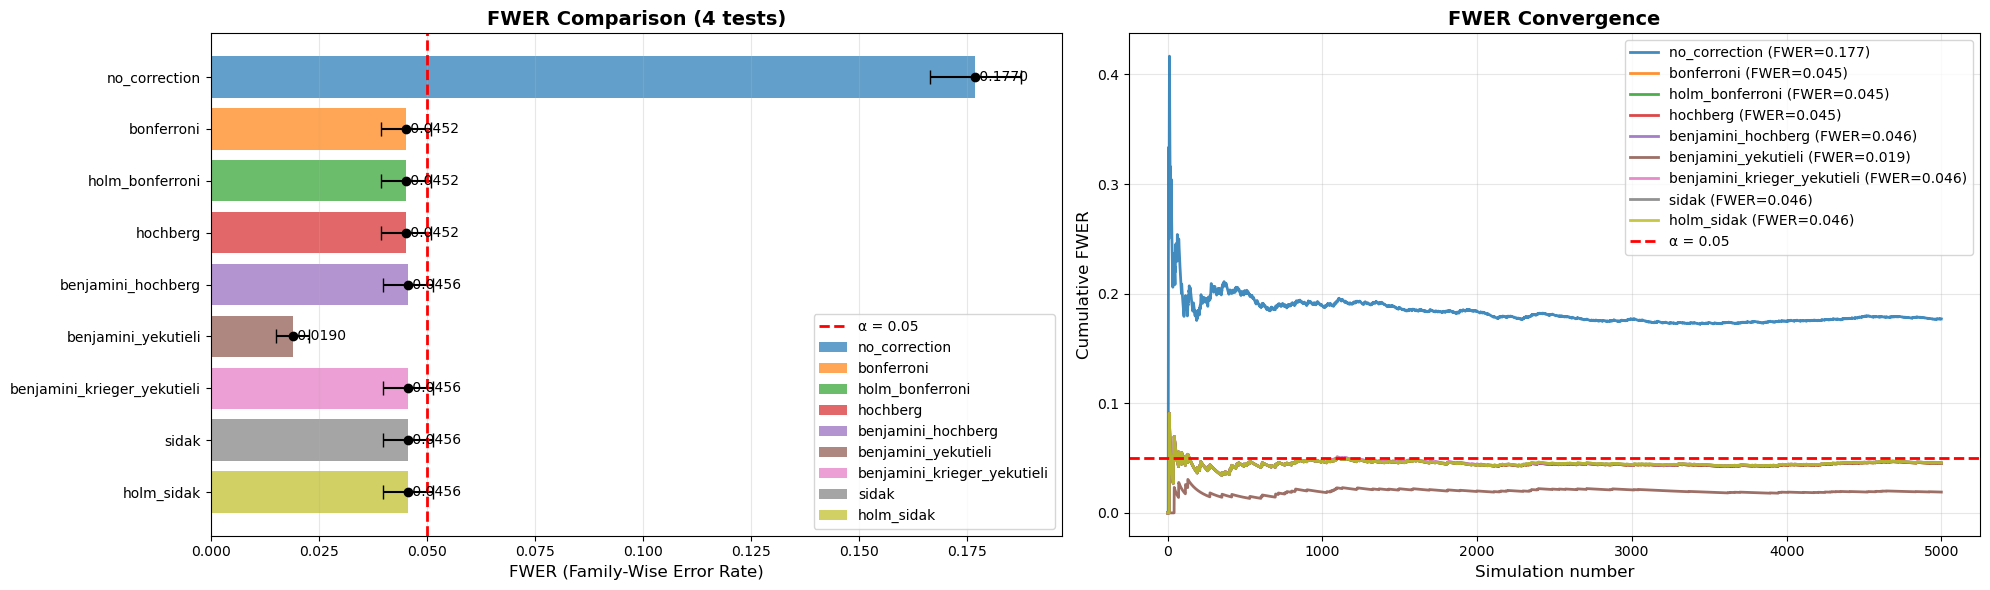

In [5]:
multi_results = bm.multi_test_1_type_error(
    multi_corrections='all',
    n_sims=5_000,
    n_jobs=-1,
    verbose=False
)

Here we can see that without correction first type error is 0.177 instead of desirable 0.05 if we track each of our 4 metrics.
Hopefully we have multiple test corrections and all of them keep error under 0.05 rate.  
Which one should we pick?  
Let's look at the power.  

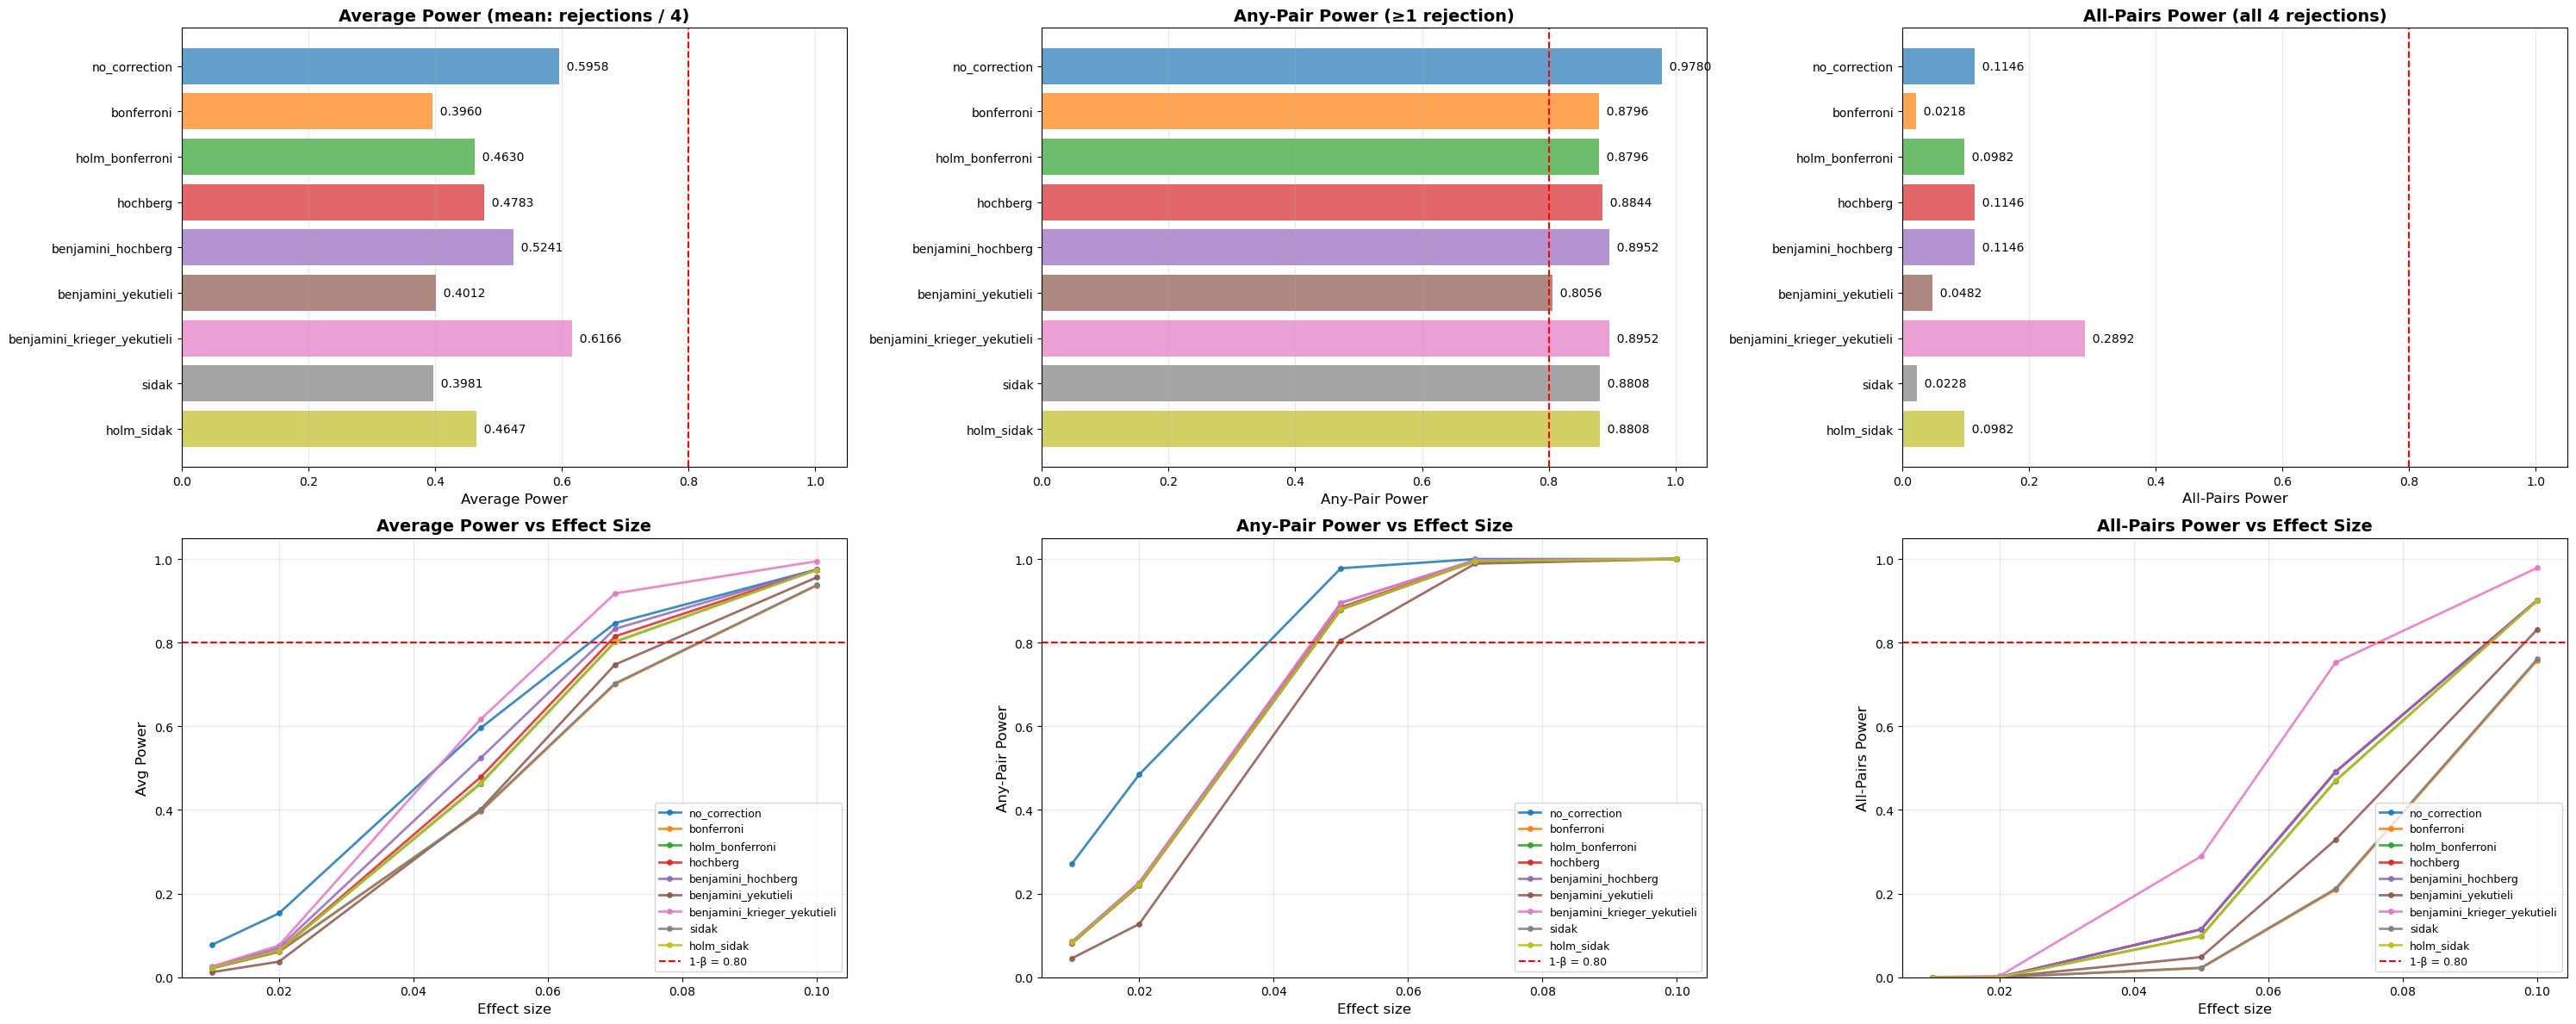

In [6]:
multi_results_power = bm.multi_test_power(
    bar_effect=0.05,
    power_curve_effects=[0.01, 0.02, 0.05, 0.07, 0.10],
    multi_corrections='all',
    n_sims=5_000,
    n_jobs=-1,
    verbose=False
)

Benjamini-Krieger-Yekutieli shows the best performance of our data.  
  
## Custom multiple corrections  
  
You can define any method by a function with raw pvalues (np.array) as argument returning corrected pvalues (np.array) and pass it as argument to BenchMarker method.  
Example:  

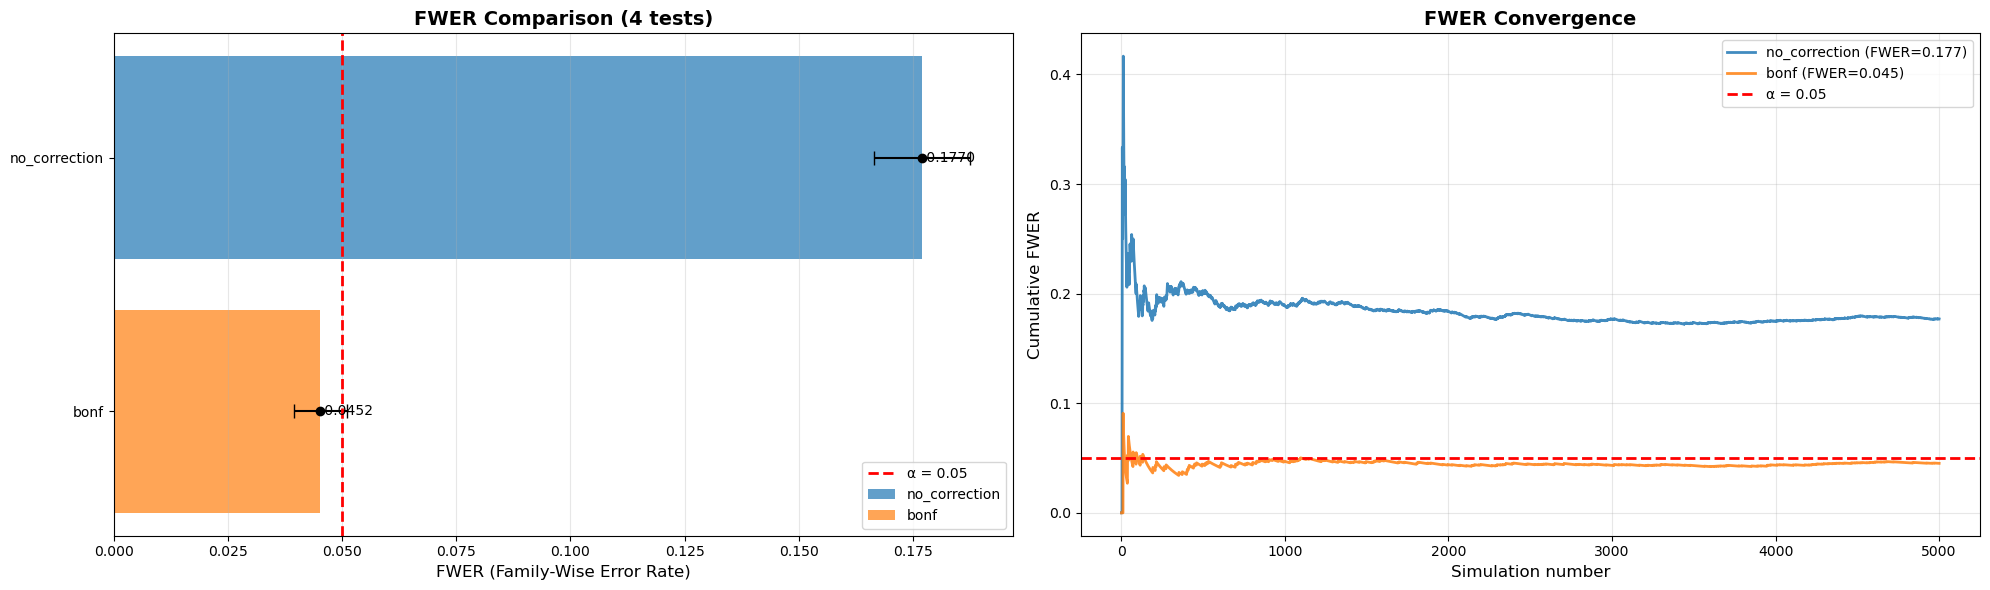

In [7]:
def bonf(pvalues):
    """Bonferroni correction."""
    m = len(pvalues)
    return np.minimum(pvalues * m, 1.0)

multi_results = bm.multi_test_1_type_error(
    multi_corrections=[('bonf', bonf)],
    n_sims=5_000,
    n_jobs=-1,
    verbose=False
)

## Summary  
  
In this lesson we looked at multiple testing deisgn.  
Hope you enjoyed the tutorial!